Nodes: 26
Links: 65


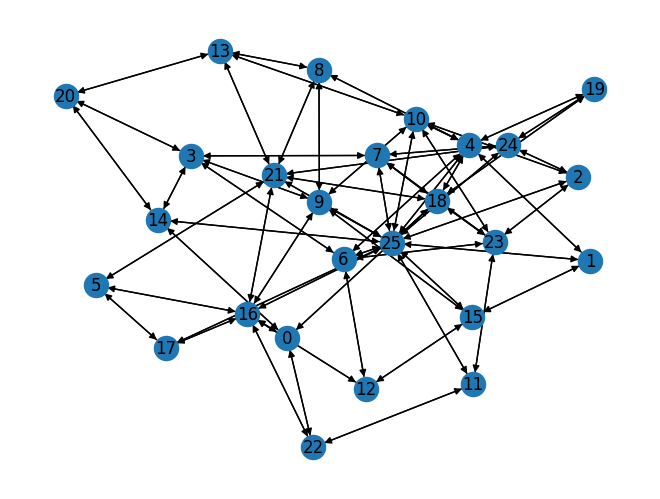

In [1]:
import networkx as nx

from edge_sim_py.components.network_switch import NetworkSwitch
from edge_sim_py.components.network_link import NetworkLink
from edge_sim_py.components.topology import Topology
from visualization.plot_topology import plot_topology
from pathlib import Path


class CaviaTopologyAdapter:

    def __init__(self, graphml_path):
        self.graphml_path = graphml_path

    def load(self):

        # Load CAVIA graph
        G = nx.read_graphml(self.graphml_path)

        pos = nx.spring_layout(G)  # layout a molle automatico
        nx.draw(G, pos, with_labels=True)

        topology = Topology()

        node_map = {}

        # --------------------
        # CREATE SWITCHES
        # --------------------

        for node_id, data in G.nodes(data=True):

            switch = NetworkSwitch()

            switch.coordinates = (float(data.get("x", 0)), float(data.get("y", 0)))

            node_map[node_id] = switch

            topology.add_node(switch)

        # --------------------
        # CREATE LINKS
        # --------------------

        for u, v, data in G.edges(data=True):

            node_u = node_map[u]
            node_v = node_map[v]

            topology.add_edge(node_u, node_v)

            link_forward = NetworkLink()
            link_forward.topology = topology
            link_forward.nodes = [node_u, node_v]

            topology._adj[node_u][node_v] = link_forward

            link_backward = NetworkLink()
            link_backward.topology = topology
            link_backward.nodes = [node_v, node_u]

            topology._adj[node_v][node_u] = link_backward

        return topology, node_map



PROJECT_ROOT = Path().resolve()

while not (PROJECT_ROOT / "scenarios").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

graph_path = PROJECT_ROOT / "scenarios/cavia/1_26_solution_v0/physical_graph.graphml"

adapter = CaviaTopologyAdapter(graph_path)

topology, node_map = adapter.load()

print("Nodes:", len(topology.nodes))
print("Links:", len(topology.edges))

#plot_topology()
